# Options Pricing for S&P 500 Index Options (SPX)

This notebook demonstrates options pricing models and Greeks calculation for S&P 500 index options. These mathematical models are fundamental to options trading strategies, risk management, and volatility trading.

We'll cover:
1. Black-Scholes model implementation
2. Greeks calculation (Delta, Gamma, Theta, Vega, Rho)
3. Implied volatility calculation and volatility smile/skew
4. Monte Carlo simulation for options pricing
5. Applications in algorithmic trading

## Setup and Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import seaborn as sns
from scipy.stats import norm
from scipy import optimize

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

## Fetch S&P 500 Data
First, let's fetch the current S&P 500 index data to get a sense of the current market levels.

In [4]:
# Get S&P 500 historical data
sp500 = yf.download('^GSPC', auto_adjust=False, period='1y')

# Display the most recent data
print(f"S&P 500 current price: ${sp500[('Close', '^GSPC')].iloc[-1]:.2f}")
print(f"52-week high: ${sp500[('High', '^GSPC')].max():.2f}")
print(f"52-week low: ${sp500[('Low', '^GSPC')].min():.2f}")

# Calculate historical volatility (annualized)
returns = np.log(sp500[('Close', '^GSPC')] / sp500[('Close', '^GSPC')].shift(1))
historical_volatility = returns.std() * np.sqrt(252)  # Annualize
print(f"Historical volatility (annualized): {historical_volatility:.2%}")

[*********************100%***********************]  1 of 1 completed

S&P 500 current price: $5604.14
52-week high: $6147.43
52-week low: $4835.04
Historical volatility (annualized): 19.33%


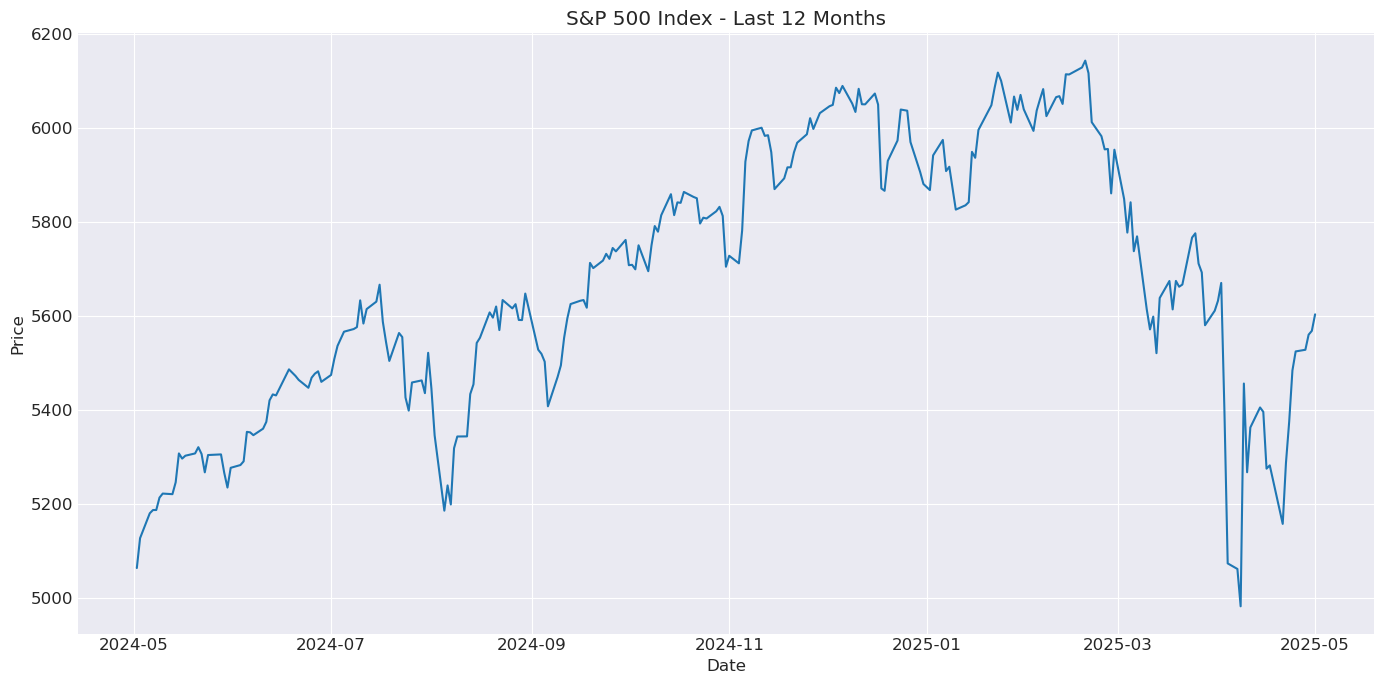

In [5]:
# Plot S&P 500 price
plt.figure(figsize=(14, 7))
plt.plot(sp500.index, sp500['Close'])
plt.title('S&P 500 Index - Last 12 Months')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

## Black-Scholes Option Pricing Model

The Black-Scholes model is a mathematical model used to determine the theoretical price of European-style options. The model assumes that the price of heavily traded assets follows a geometric Brownian motion with constant drift and volatility.

The Black-Scholes formula for European call and put options is:

**Call Option Price:**
$$C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

**Put Option Price:**
$$P = K \cdot e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

Where:
- $S$ = Current stock price
- $K$ = Strike price
- $r$ = Risk-free interest rate
- $T$ = Time to expiration (in years)
- $\sigma$ = Volatility of the underlying asset
- $N()$ = Cumulative distribution function of the standard normal distribution
- $d_1 = \frac{\ln(\frac{S}{K}) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$
- $d_2 = d_1 - \sigma\sqrt{T}$

Let's implement this model:

In [6]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    Calculate Black-Scholes option price for a European option
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: Time to expiration (in years)
    r: Risk-free interest rate
    sigma: Volatility
    option_type: 'call' or 'put'
    
    Returns:
    Option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type.lower() == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type.lower() == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
        
    return price

Let's create a function to calculate the option Greeks, which are important for understanding option price sensitivity to various factors.

In [7]:
def black_scholes_greeks(S, K, T, r, sigma, option_type='call'):
    """
    Calculate Black-Scholes option Greeks
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: Time to expiration (in years)
    r: Risk-free interest rate
    sigma: Volatility
    option_type: 'call' or 'put'
    
    Returns:
    Dictionary containing the option price and Greeks
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Option price
    if option_type.lower() == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type.lower() == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    # Common Greeks for both call and put options
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))  # Second derivative w.r.t. S
    vega = S * np.sqrt(T) * norm.pdf(d1) / 100  # Derivative w.r.t. sigma (divided by 100 for 1% change)
    rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100 if option_type.lower() == 'call' else -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100  # Derivative w.r.t. r (divided by 100 for 1% change)
    
    return {
        'price': price,
        'delta': delta,
        'gamma': gamma,
        'theta': theta / 365,  # Convert to daily theta
        'vega': vega,
        'rho': rho
    }

## Calculate Option Prices and Greeks

Let's calculate prices and Greeks for some sample S&P 500 options.

In [10]:
# Set current S&P 500 level and option parameters
S = float(sp500['Close'].iloc[-1])  # Convert to scalar float
r = 0.05  # 5% risk-free rate (adjust based on current rates)
sigma = float(historical_volatility)  # Convert to scalar float

# Example: 30-day options at different strike prices
T = 30 / 365  # 30 days to expiration (in years)

# Generate strike prices around the current price
strike_range = np.linspace(S * 0.9, S * 1.1, 11)  # From 90% to 110% of current price

# Helper function to extract scalar values
def extract_scalar(value):
    if isinstance(value, pd.Series):
        return float(value.iloc[0])
    elif isinstance(value, np.ndarray):
        return float(value[0])
    return float(value)

# Calculate call and put prices and Greeks for each strike
results = []
for K in strike_range:
    # Call option
    call_greeks = black_scholes_greeks(S, K, T, r, sigma, 'call')
    call_results = {
        'Strike': extract_scalar(K),
        'Type': 'Call',
        'Price': extract_scalar(call_greeks['price']),
        'Delta': extract_scalar(call_greeks['delta']),
        'Gamma': extract_scalar(call_greeks['gamma']),
        'Theta': extract_scalar(call_greeks['theta']),
        'Vega': extract_scalar(call_greeks['vega']),
        'Rho': extract_scalar(call_greeks['rho'])
    }
    results.append(call_results)
    
    # Put option
    put_greeks = black_scholes_greeks(S, K, T, r, sigma, 'put')
    put_results = {
        'Strike': extract_scalar(K),
        'Type': 'Put',
        'Price': extract_scalar(put_greeks['price']),
        'Delta': extract_scalar(put_greeks['delta']),
        'Gamma': extract_scalar(put_greeks['gamma']),
        'Theta': extract_scalar(put_greeks['theta']),
        'Vega': extract_scalar(put_greeks['vega']),
        'Rho': extract_scalar(put_greeks['rho'])
    }
    results.append(put_results)

# Create a DataFrame with the results
options_df = pd.DataFrame(results)

# Display results
pd.set_option('display.precision', 4)
print(f"Current S&P 500 price: ${S:.2f}")
print(f"Option pricing for 30-day options:")
display(options_df)

Current S&P 500 price: $5604.14
Option pricing for 30-day options:


/tmp/ipykernel_2557/396403766.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S = float(sp500['Close'].iloc[-1])  # Convert to scalar float


,Strike,Type,Price,Delta,Gamma,Theta,Vega,Rho
0,5043.7261,Call,583.7631,0.9774,0.0002,-0.9480,0.8618,4.0223
1,5043.7261,Put,2.6640,-0.0226,0.0002,-0.2599,0.8618,-0.1062
2,5155.8089,Call,476.7339,0.9459,0.0004,-1.2289,1.7634,3.9652
3,5155.8089,Put,7.2579,-0.0541,0.0004,-0.5255,1.7634,-0.2550
4,5267.8917,Call,375.0263,0.8885,0.0006,-1.6135,3.0509,3.7842
5,5267.8917,Put,17.1734,-0.1115,0.0006,-0.8949,3.0509,-0.5278
6,5379.9745,Call,282.0290,0.7991,0.0009,-2.0276,4.5096,3.4492
7,5379.9745,Put,35.7992,-0.2009,0.0009,-1.2936,4.5096,-0.9546
8,5492.0573,Call,201.2786,0.6796,0.0012,-2.3461,5.7489,2.9647
9,5492.0573,Put,66.6720,-0.3204,0.0012,-1.5968,5.7489,-1.5308


## Visualizing Option Prices and Greeks

Let's visualize how option prices and Greeks change with different strike prices.

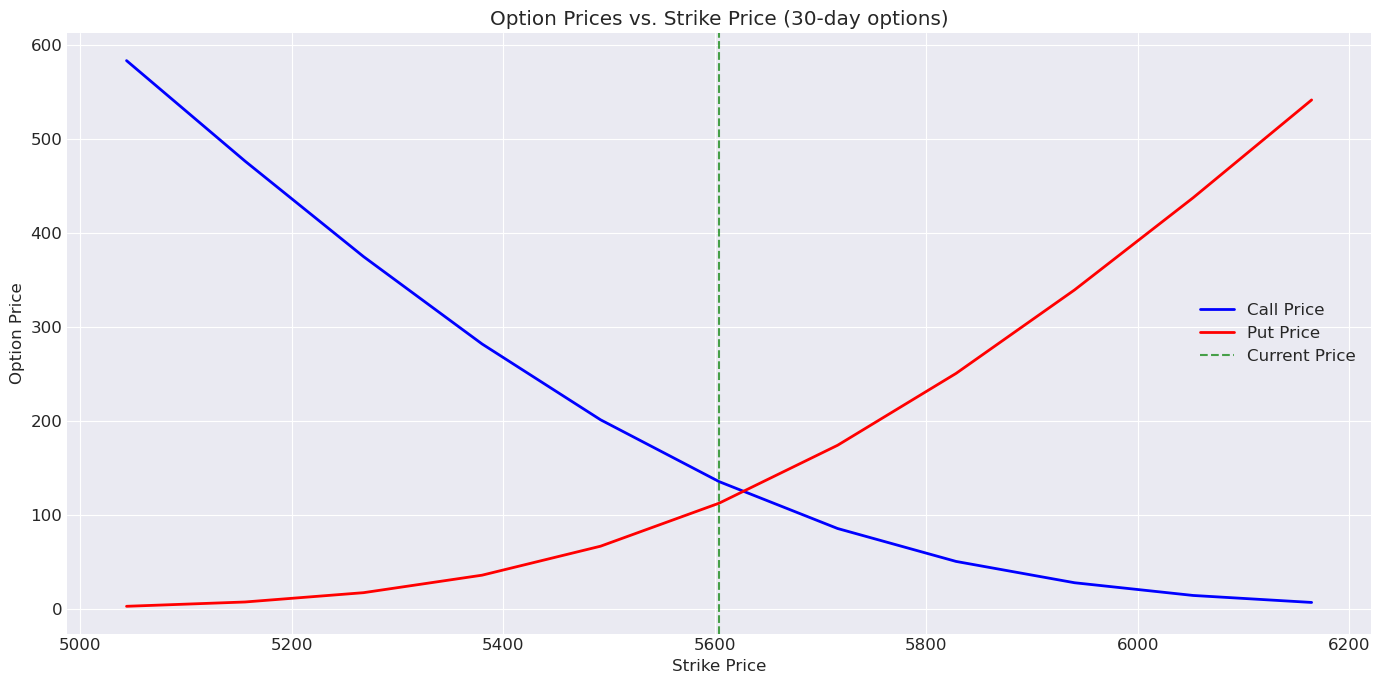

In [11]:
# Filter data for calls and puts
calls = options_df[options_df['Type'] == 'Call']
puts = options_df[options_df['Type'] == 'Put']

# Plot option prices
plt.figure(figsize=(14, 7))
plt.plot(calls['Strike'], calls['Price'], 'b-', linewidth=2, label='Call Price')
plt.plot(puts['Strike'], puts['Price'], 'r-', linewidth=2, label='Put Price')
plt.axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
plt.title('Option Prices vs. Strike Price (30-day options)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

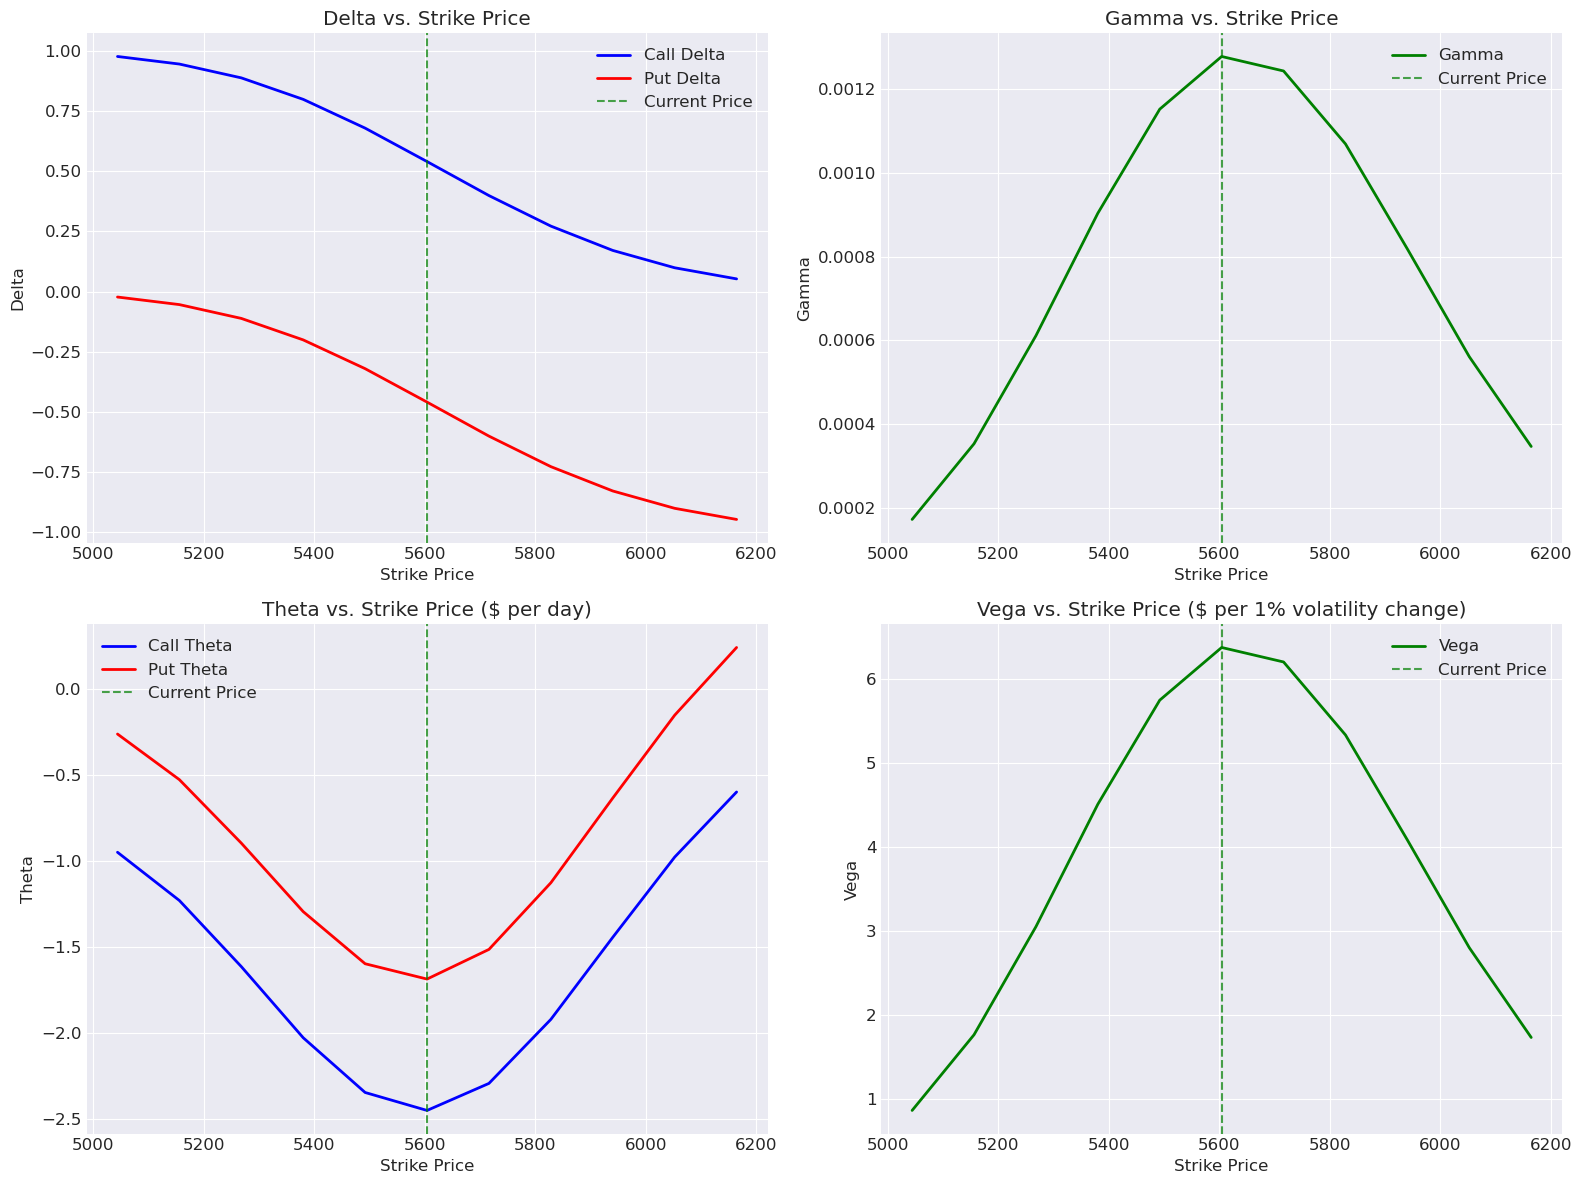

In [12]:
# Plot option Greeks
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Delta
axs[0, 0].plot(calls['Strike'], calls['Delta'], 'b-', linewidth=2, label='Call Delta')
axs[0, 0].plot(puts['Strike'], puts['Delta'], 'r-', linewidth=2, label='Put Delta')
axs[0, 0].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[0, 0].set_title('Delta vs. Strike Price')
axs[0, 0].set_xlabel('Strike Price')
axs[0, 0].set_ylabel('Delta')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Gamma (same for calls and puts)
axs[0, 1].plot(calls['Strike'], calls['Gamma'], 'g-', linewidth=2, label='Gamma')
axs[0, 1].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[0, 1].set_title('Gamma vs. Strike Price')
axs[0, 1].set_xlabel('Strike Price')
axs[0, 1].set_ylabel('Gamma')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Theta
axs[1, 0].plot(calls['Strike'], calls['Theta'], 'b-', linewidth=2, label='Call Theta')
axs[1, 0].plot(puts['Strike'], puts['Theta'], 'r-', linewidth=2, label='Put Theta')
axs[1, 0].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[1, 0].set_title('Theta vs. Strike Price ($ per day)')
axs[1, 0].set_xlabel('Strike Price')
axs[1, 0].set_ylabel('Theta')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Vega (same for calls and puts)
axs[1, 1].plot(calls['Strike'], calls['Vega'], 'g-', linewidth=2, label='Vega')
axs[1, 1].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[1, 1].set_title('Vega vs. Strike Price ($ per 1% volatility change)')
axs[1, 1].set_xlabel('Strike Price')
axs[1, 1].set_ylabel('Vega')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

## Option Prices Across Time to Expiration

Let's analyze how option prices and Greeks vary with different expiration dates.

In [13]:
# Set fixed parameters
K = S  # At-the-money option

# Generate different expiration times
days_to_expiry = [7, 14, 30, 60, 90, 180, 365]  # Days
expiries = [d / 365 for d in days_to_expiry]  # Convert to years

# Calculate call and put prices for different expiries
time_results = []
for T in expiries:
    # Call option
    call_greeks = black_scholes_greeks(S, K, T, r, sigma, 'call')
    call_results = {
        'Days': T * 365,
        'Type': 'Call',
        'Price': call_greeks['price'],
        'Delta': call_greeks['delta'],
        'Gamma': call_greeks['gamma'],
        'Theta': call_greeks['theta'],
        'Vega': call_greeks['vega'],
        'Rho': call_greeks['rho']
    }
    time_results.append(call_results)
    
    # Put option
    put_greeks = black_scholes_greeks(S, K, T, r, sigma, 'put')
    put_results = {
        'Days': T * 365,
        'Type': 'Put',
        'Price': put_greeks['price'],
        'Delta': put_greeks['delta'],
        'Gamma': put_greeks['gamma'],
        'Theta': put_greeks['theta'],
        'Vega': put_greeks['vega'],
        'Rho': put_greeks['rho']
    }
    time_results.append(put_results)

# Create a DataFrame with the results
time_df = pd.DataFrame(time_results)

# Display results
print(f"Option pricing for at-the-money options (K = ${K:.2f}):")
display(time_df)

Option pricing for at-the-money options (K = $5604.14):


,Days,Type,Price,Delta,Gamma,Theta,Vega,Rho
0,7.0,Call,62.5373,0.5196,0.0027,-4.6597,3.0924,0.5465
1,7.0,Put,57.1661,-0.4804,0.0027,-3.8928,3.0924,-0.5273
2,14.0,Call,90.0229,0.5277,0.0019,-3.4081,4.3680,1.0999
3,14.0,Put,79.2856,-0.4723,0.0019,-2.6418,4.3680,-1.0455
4,30.0,Call,135.4500,0.5406,0.0013,-2.4506,6.3765,2.3786
5,30.0,Put,112.4665,-0.4594,0.0013,-1.6860,6.3765,-2.2086
6,60.0,Call,198.3374,0.5573,0.0009,-1.8456,8.9710,4.8077
7,60.0,Put,152.4647,-0.4427,0.0009,-1.0842,8.9710,-4.3291
8,90.0,Call,249.2736,0.5700,0.0007,-1.5772,10.9303,7.2622
9,90.0,Put,180.6056,-0.4300,0.0007,-0.8189,10.9303,-6.3869


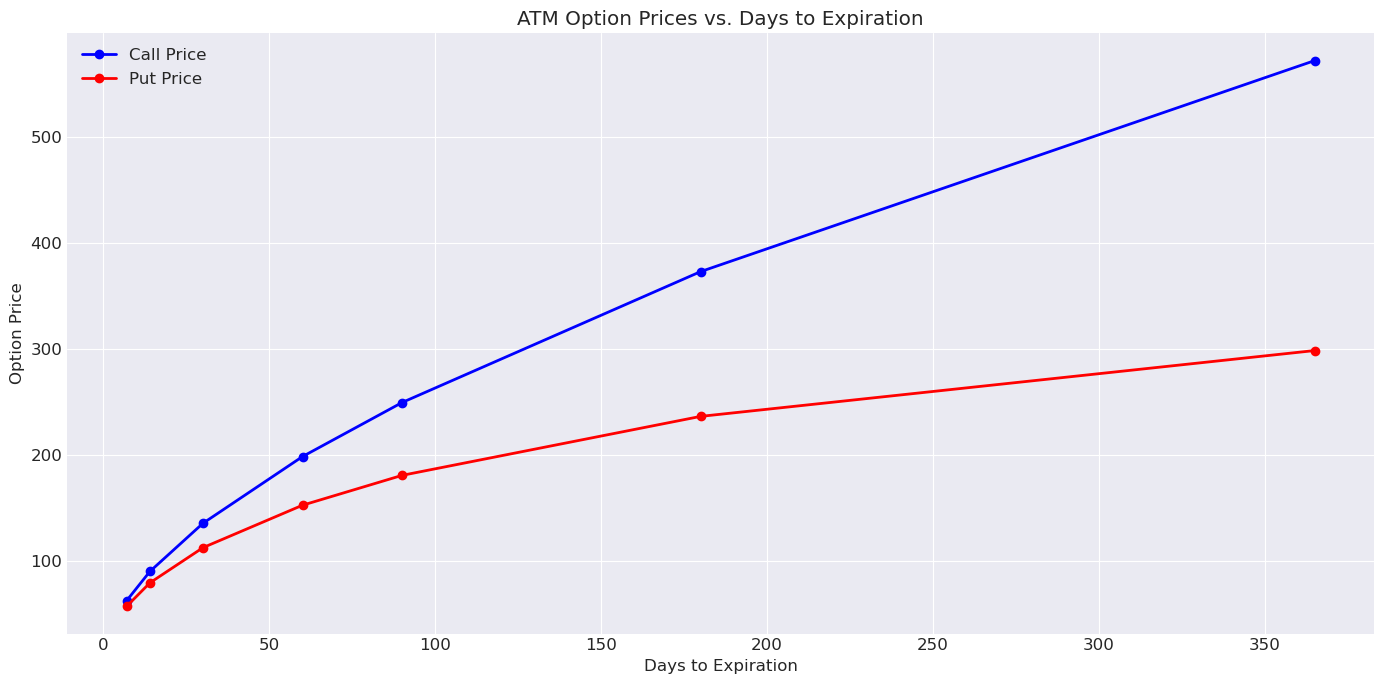

In [14]:
# Filter data for calls and puts
time_calls = time_df[time_df['Type'] == 'Call']
time_puts = time_df[time_df['Type'] == 'Put']

# Plot option prices vs. time to expiration
plt.figure(figsize=(14, 7))
plt.plot(time_calls['Days'], time_calls['Price'], 'b-o', linewidth=2, label='Call Price')
plt.plot(time_puts['Days'], time_puts['Price'], 'r-o', linewidth=2, label='Put Price')
plt.title('ATM Option Prices vs. Days to Expiration')
plt.xlabel('Days to Expiration')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

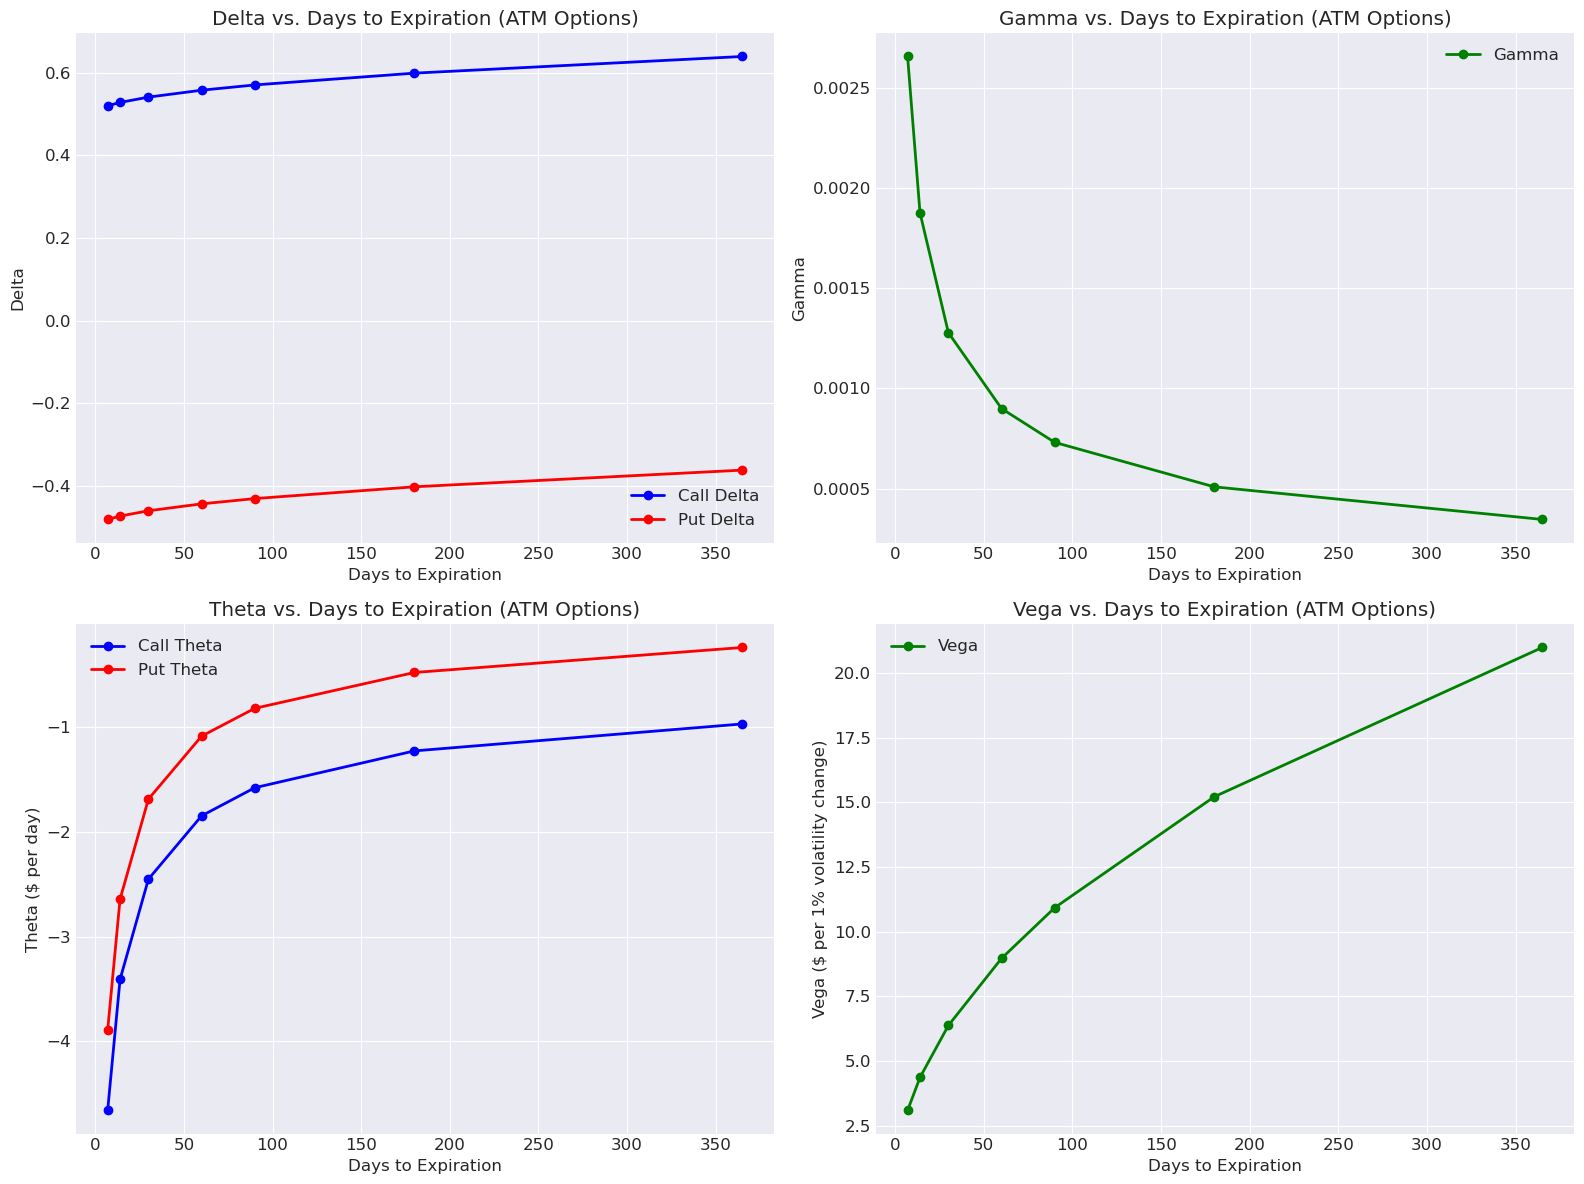

In [15]:
# Plot option Greeks vs. time to expiration
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Delta
axs[0, 0].plot(time_calls['Days'], time_calls['Delta'], 'b-o', linewidth=2, label='Call Delta')
axs[0, 0].plot(time_puts['Days'], time_puts['Delta'], 'r-o', linewidth=2, label='Put Delta')
axs[0, 0].set_title('Delta vs. Days to Expiration (ATM Options)')
axs[0, 0].set_xlabel('Days to Expiration')
axs[0, 0].set_ylabel('Delta')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Gamma
axs[0, 1].plot(time_calls['Days'], time_calls['Gamma'], 'g-o', linewidth=2, label='Gamma')
axs[0, 1].set_title('Gamma vs. Days to Expiration (ATM Options)')
axs[0, 1].set_xlabel('Days to Expiration')
axs[0, 1].set_ylabel('Gamma')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Theta
axs[1, 0].plot(time_calls['Days'], time_calls['Theta'], 'b-o', linewidth=2, label='Call Theta')
axs[1, 0].plot(time_puts['Days'], time_puts['Theta'], 'r-o', linewidth=2, label='Put Theta')
axs[1, 0].set_title('Theta vs. Days to Expiration (ATM Options)')
axs[1, 0].set_xlabel('Days to Expiration')
axs[1, 0].set_ylabel('Theta ($ per day)')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Vega
axs[1, 1].plot(time_calls['Days'], time_calls['Vega'], 'g-o', linewidth=2, label='Vega')
axs[1, 1].set_title('Vega vs. Days to Expiration (ATM Options)')
axs[1, 1].set_xlabel('Days to Expiration')
axs[1, 1].set_ylabel('Vega ($ per 1% volatility change)')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

## Implied Volatility Calculation

Implied volatility (IV) is the market's forecast of a likely movement in the underlying asset's price. Let's implement a function to calculate implied volatility from market prices.

In [16]:
def calculate_implied_volatility(market_price, S, K, T, r, option_type='call'):
    """
    Calculate implied volatility using the bisection method
    
    Parameters:
    market_price: Market price of the option
    S: Current stock price
    K: Strike price
    T: Time to expiration (in years)
    r: Risk-free interest rate
    option_type: 'call' or 'put'
    
    Returns:
    Implied volatility (annualized)
    """
    def objective_function(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - market_price
    
    # Use scipy's root-finding to find implied volatility
    try:
        result = optimize.brentq(objective_function, 0.001, 5.0, rtol=1e-6)
        return result
    except ValueError:
        return np.nan

## Simulating Volatility Smile/Skew

In real markets, the implied volatility varies with strike price, creating what's known as the volatility smile or skew. Let's simulate this phenomenon for S&P 500 options.

In [17]:
# Simulate market prices with volatility skew
def simulate_market_prices_with_skew(S, strikes, T, r, base_volatility):
    """
    Simulate market prices with a volatility skew (higher IV for OTM puts, lower for OTM calls)
    """
    results = []
    
    for K in strikes:
        # Calculate moneyness (K/S)
        moneyness = K / S
        
        # Simulate volatility skew (typical for equity indices like S&P 500)
        if moneyness < 1:  # OTM put / ITM call
            skew_factor = 1 + 0.2 * (1 - moneyness) ** 2  # Higher IV for OTM puts
        else:  # ITM put / OTM call
            skew_factor = 1 + 0.05 * (moneyness - 1) ** 2  # Slightly higher IV for deep OTM calls
            
        # Adjust volatility based on skew
        adjusted_volatility = base_volatility * skew_factor
        
        # Calculate prices with adjusted volatility
        call_price = black_scholes(S, K, T, r, adjusted_volatility, 'call')
        put_price = black_scholes(S, K, T, r, adjusted_volatility, 'put')
        
        # Store results
        results.append({
            'Strike': K,
            'Moneyness': moneyness,
            'IV': adjusted_volatility,
            'Call Price': call_price,
            'Put Price': put_price
        })
    
    return pd.DataFrame(results)

In [18]:
# Generate more detailed strike range
strikes = np.linspace(S * 0.8, S * 1.2, 21)  # From 80% to 120% of current price

# Simulate market with volatility skew
T = 30 / 365  # 30-day options
market_data = simulate_market_prices_with_skew(S, strikes, T, r, historical_volatility)

# Display results
print(f"Simulated market prices with volatility skew (30-day options):")
display(market_data.head())

Simulated market prices with volatility skew (30-day options):


,Strike,Moneyness,IV,Call Price,Put Price
0,4483.3121,0.80,0.1948,1139.2163,0.0015
1,4595.3949,0.82,0.1945,1027.6014,0.0097
2,4707.4777,0.84,0.1943,916.0206,0.0521
3,4819.5605,0.86,0.1940,804.5762,0.2308
4,4931.6433,0.88,0.1938,693.5789,0.8566


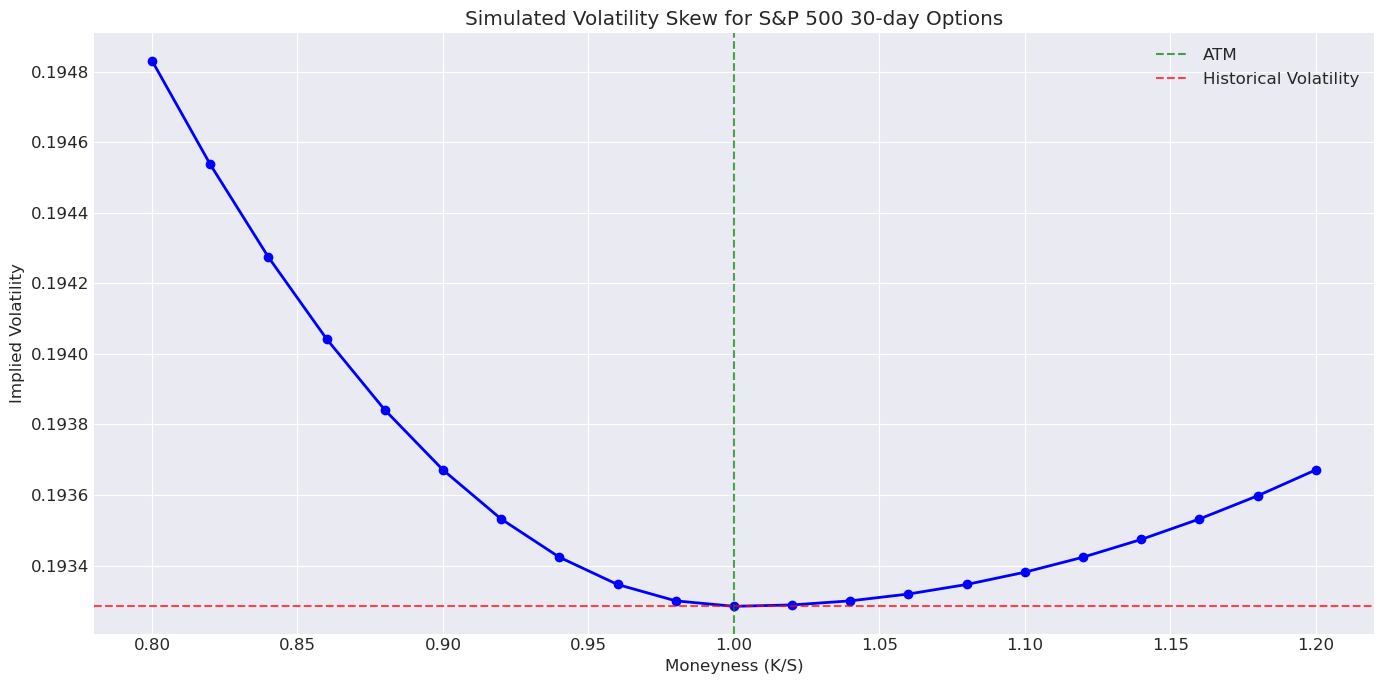

In [19]:
# Plot volatility skew/smile
plt.figure(figsize=(14, 7))
plt.plot(market_data['Moneyness'], market_data['IV'], 'bo-', linewidth=2)
plt.axvline(x=1, color='green', linestyle='--', alpha=0.7, label='ATM')
plt.axhline(y=historical_volatility, color='red', linestyle='--', alpha=0.7, label='Historical Volatility')
plt.title('Simulated Volatility Skew for S&P 500 30-day Options')
plt.xlabel('Moneyness (K/S)')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Monte Carlo Simulation for Option Pricing

The Black-Scholes model makes several assumptions that may not hold in real markets. Monte Carlo simulation provides a more flexible approach for option pricing, especially for complex options.

In [20]:
def monte_carlo_option_price(S, K, T, r, sigma, option_type='call', n_simulations=10000, n_steps=252):
    """
    Price an option using Monte Carlo simulation
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: Time to expiration (in years)
    r: Risk-free interest rate
    sigma: Volatility
    option_type: 'call' or 'put'
    n_simulations: Number of simulated price paths
    n_steps: Number of time steps in each simulation
    
    Returns:
    Option price and standard error
    """
    dt = T / n_steps  # Time step
    
    # Simulate price paths
    price_paths = np.zeros((n_simulations, n_steps + 1))
    price_paths[:, 0] = S
    
    for t in range(1, n_steps + 1):
        # Generate random shocks
        Z = np.random.standard_normal(n_simulations)
        
        # Update prices
        price_paths[:, t] = price_paths[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    # Calculate payoffs at expiration
    if option_type.lower() == 'call':
        payoffs = np.maximum(price_paths[:, -1] - K, 0)
    elif option_type.lower() == 'put':
        payoffs = np.maximum(K - price_paths[:, -1], 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    # Discount payoffs to present value
    option_price = np.exp(-r * T) * np.mean(payoffs)
    option_std_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_simulations)
    
    return {
        'price': option_price,
        'std_error': option_std_error,
        'price_paths': price_paths
    }

In [21]:
# Price an at-the-money call option using Monte Carlo simulation
K = S  # At-the-money option
T = 30 / 365  # 30-day option

# Run Monte Carlo simulation
mc_call = monte_carlo_option_price(S, K, T, r, sigma, 'call', n_simulations=10000)
mc_put = monte_carlo_option_price(S, K, T, r, sigma, 'put', n_simulations=10000)

# Compare with Black-Scholes price
bs_call = black_scholes(S, K, T, r, sigma, 'call')
bs_put = black_scholes(S, K, T, r, sigma, 'put')

print(f"\nOption pricing for 30-day ATM options (K = ${K:.2f}):")
print(f"Call Option:")
print(f"  Monte Carlo: ${mc_call['price']:.2f} ± ${mc_call['std_error']:.2f}")
print(f"  Black-Scholes: ${bs_call:.2f}")
print(f"  Difference: ${mc_call['price'] - bs_call:.2f} ({(mc_call['price'] - bs_call) / bs_call * 100:.2f}%)")

print(f"\nPut Option:")
print(f"  Monte Carlo: ${mc_put['price']:.2f} ± ${mc_put['std_error']:.2f}")
print(f"  Black-Scholes: ${bs_put:.2f}")
print(f"  Difference: ${mc_put['price'] - bs_put:.2f} ({(mc_put['price'] - bs_put) / bs_put * 100:.2f}%)")


Option pricing for 30-day ATM options (K = $5604.14):
Call Option:
  Monte Carlo: $134.06 ± $1.93
  Black-Scholes: $135.45
  Difference: $-1.39 (-1.03%)

Put Option:
  Monte Carlo: $110.59 ± $1.65
  Black-Scholes: $112.47
  Difference: $-1.88 (-1.67%)


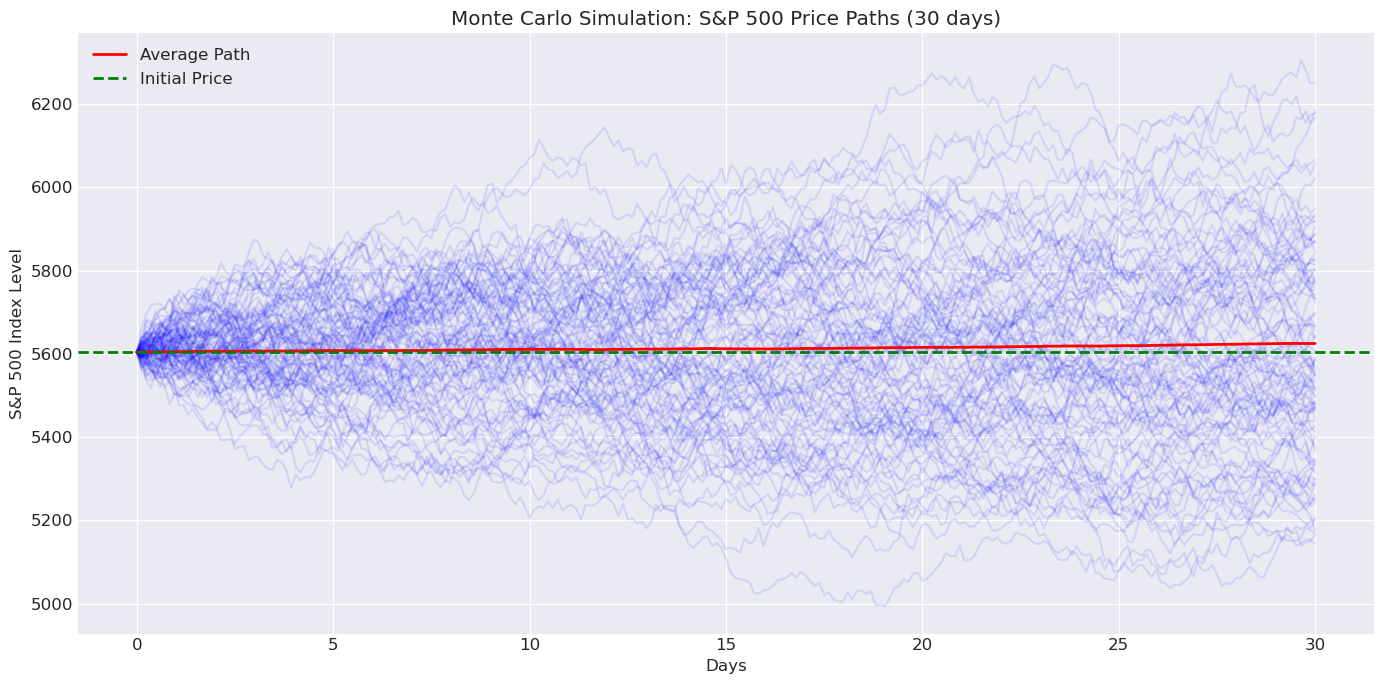

In [22]:
# Plot some sample price paths from the Monte Carlo simulation
plt.figure(figsize=(14, 7))

# Plot 100 random paths
sample_paths = mc_call['price_paths'][np.random.choice(mc_call['price_paths'].shape[0], 100, replace=False)]
for i in range(sample_paths.shape[0]):
    plt.plot(np.linspace(0, T*365, sample_paths.shape[1]), sample_paths[i], 'b-', alpha=0.1)

# Plot the average path
avg_path = np.mean(mc_call['price_paths'], axis=0)
plt.plot(np.linspace(0, T*365, len(avg_path)), avg_path, 'r-', linewidth=2, label='Average Path')

# Add initial price line
plt.axhline(y=S, color='green', linestyle='--', linewidth=2, label='Initial Price')

plt.title('Monte Carlo Simulation: S&P 500 Price Paths (30 days)')
plt.xlabel('Days')
plt.ylabel('S&P 500 Index Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Options Strategies for S&P 500 Trading

Let's explore some common options strategies used in algorithmic trading of S&P 500 options.

In [23]:
def calculate_strategy_payoff(strategy, spot_range):
    """
    Calculate the payoff of an options strategy at expiration
    
    Parameters:
    strategy: List of dictionaries, each containing:
              - 'type': 'call' or 'put'
              - 'position': 'long' or 'short'
              - 'strike': Strike price
              - 'premium': Option premium (price)
              - 'quantity': Number of contracts (positive for long, negative for short)
    spot_range: Range of spot prices at expiration to calculate payoff for
    
    Returns:
    DataFrame with payoff at each spot price
    """
    payoffs = []
    
    for spot in spot_range:
        strategy_payoff = 0
        for option in strategy:
            option_type = option['type']
            strike = option['strike']
            premium = option['premium']
            quantity = option['quantity']
            
            # Calculate intrinsic value at expiration
            if option_type == 'call':
                intrinsic = max(0, spot - strike)
            else:  # put
                intrinsic = max(0, strike - spot)
            
            # Calculate payoff (intrinsic value minus premium)
            option_payoff = quantity * (intrinsic - premium)
            strategy_payoff += option_payoff
        
        payoffs.append({
            'Spot': spot,
            'Payoff': strategy_payoff
        })
    
    return pd.DataFrame(payoffs)

In [24]:
# Define strategy functions
def long_straddle(S, K, T, r, sigma):
    """
    Create a long straddle strategy (long call + long put at same strike)
    """
    call_price = black_scholes(S, K, T, r, sigma, 'call')
    put_price = black_scholes(S, K, T, r, sigma, 'put')
    
    return [
        {'type': 'call', 'position': 'long', 'strike': K, 'premium': call_price, 'quantity': 1},
        {'type': 'put', 'position': 'long', 'strike': K, 'premium': put_price, 'quantity': 1}
    ]

def iron_condor(S, width=0.05, wing_width=0.05, T=30/365, r=0.05, sigma=0.2):
    """
    Create an iron condor strategy
    """
    # Define strikes
    lower_put = S * (1 - width - wing_width)  # Lower put (buy)
    upper_put = S * (1 - width)               # Upper put (sell)
    lower_call = S * (1 + width)              # Lower call (sell)
    upper_call = S * (1 + width + wing_width) # Upper call (buy)
    
    # Calculate prices
    lower_put_price = black_scholes(S, lower_put, T, r, sigma, 'put')
    upper_put_price = black_scholes(S, upper_put, T, r, sigma, 'put')
    lower_call_price = black_scholes(S, lower_call, T, r, sigma, 'call')
    upper_call_price = black_scholes(S, upper_call, T, r, sigma, 'call')
    
    return [
        {'type': 'put', 'position': 'long', 'strike': lower_put, 'premium': lower_put_price, 'quantity': 1},
        {'type': 'put', 'position': 'short', 'strike': upper_put, 'premium': upper_put_price, 'quantity': -1},
        {'type': 'call', 'position': 'short', 'strike': lower_call, 'premium': lower_call_price, 'quantity': -1},
        {'type': 'call', 'position': 'long', 'strike': upper_call, 'premium': upper_call_price, 'quantity': 1}
    ]

def bull_call_spread(S, width=0.05, T=30/365, r=0.05, sigma=0.2):
    """
    Create a bull call spread strategy
    """
    lower_strike = S  # At-the-money
    upper_strike = S * (1 + width)  # OTM call
    
    lower_call_price = black_scholes(S, lower_strike, T, r, sigma, 'call')
    upper_call_price = black_scholes(S, upper_strike, T, r, sigma, 'call')
    
    return [
        {'type': 'call', 'position': 'long', 'strike': lower_strike, 'premium': lower_call_price, 'quantity': 1},
        {'type': 'call', 'position': 'short', 'strike': upper_strike, 'premium': upper_call_price, 'quantity': -1}
    ]

In [25]:
# Create strategies
straddle = long_straddle(S, S, T, r, sigma)  # ATM straddle
iron_condor_strategy = iron_condor(S, width=0.05, wing_width=0.05, T=T, r=r, sigma=sigma)
bull_spread = bull_call_spread(S, width=0.05, T=T, r=r, sigma=sigma)

# Generate spot price range for payoff calculation
spot_range = np.linspace(S * 0.8, S * 1.2, 100)

# Calculate payoffs
straddle_payoff = calculate_strategy_payoff(straddle, spot_range)
iron_condor_payoff = calculate_strategy_payoff(iron_condor_strategy, spot_range)
bull_spread_payoff = calculate_strategy_payoff(bull_spread, spot_range)

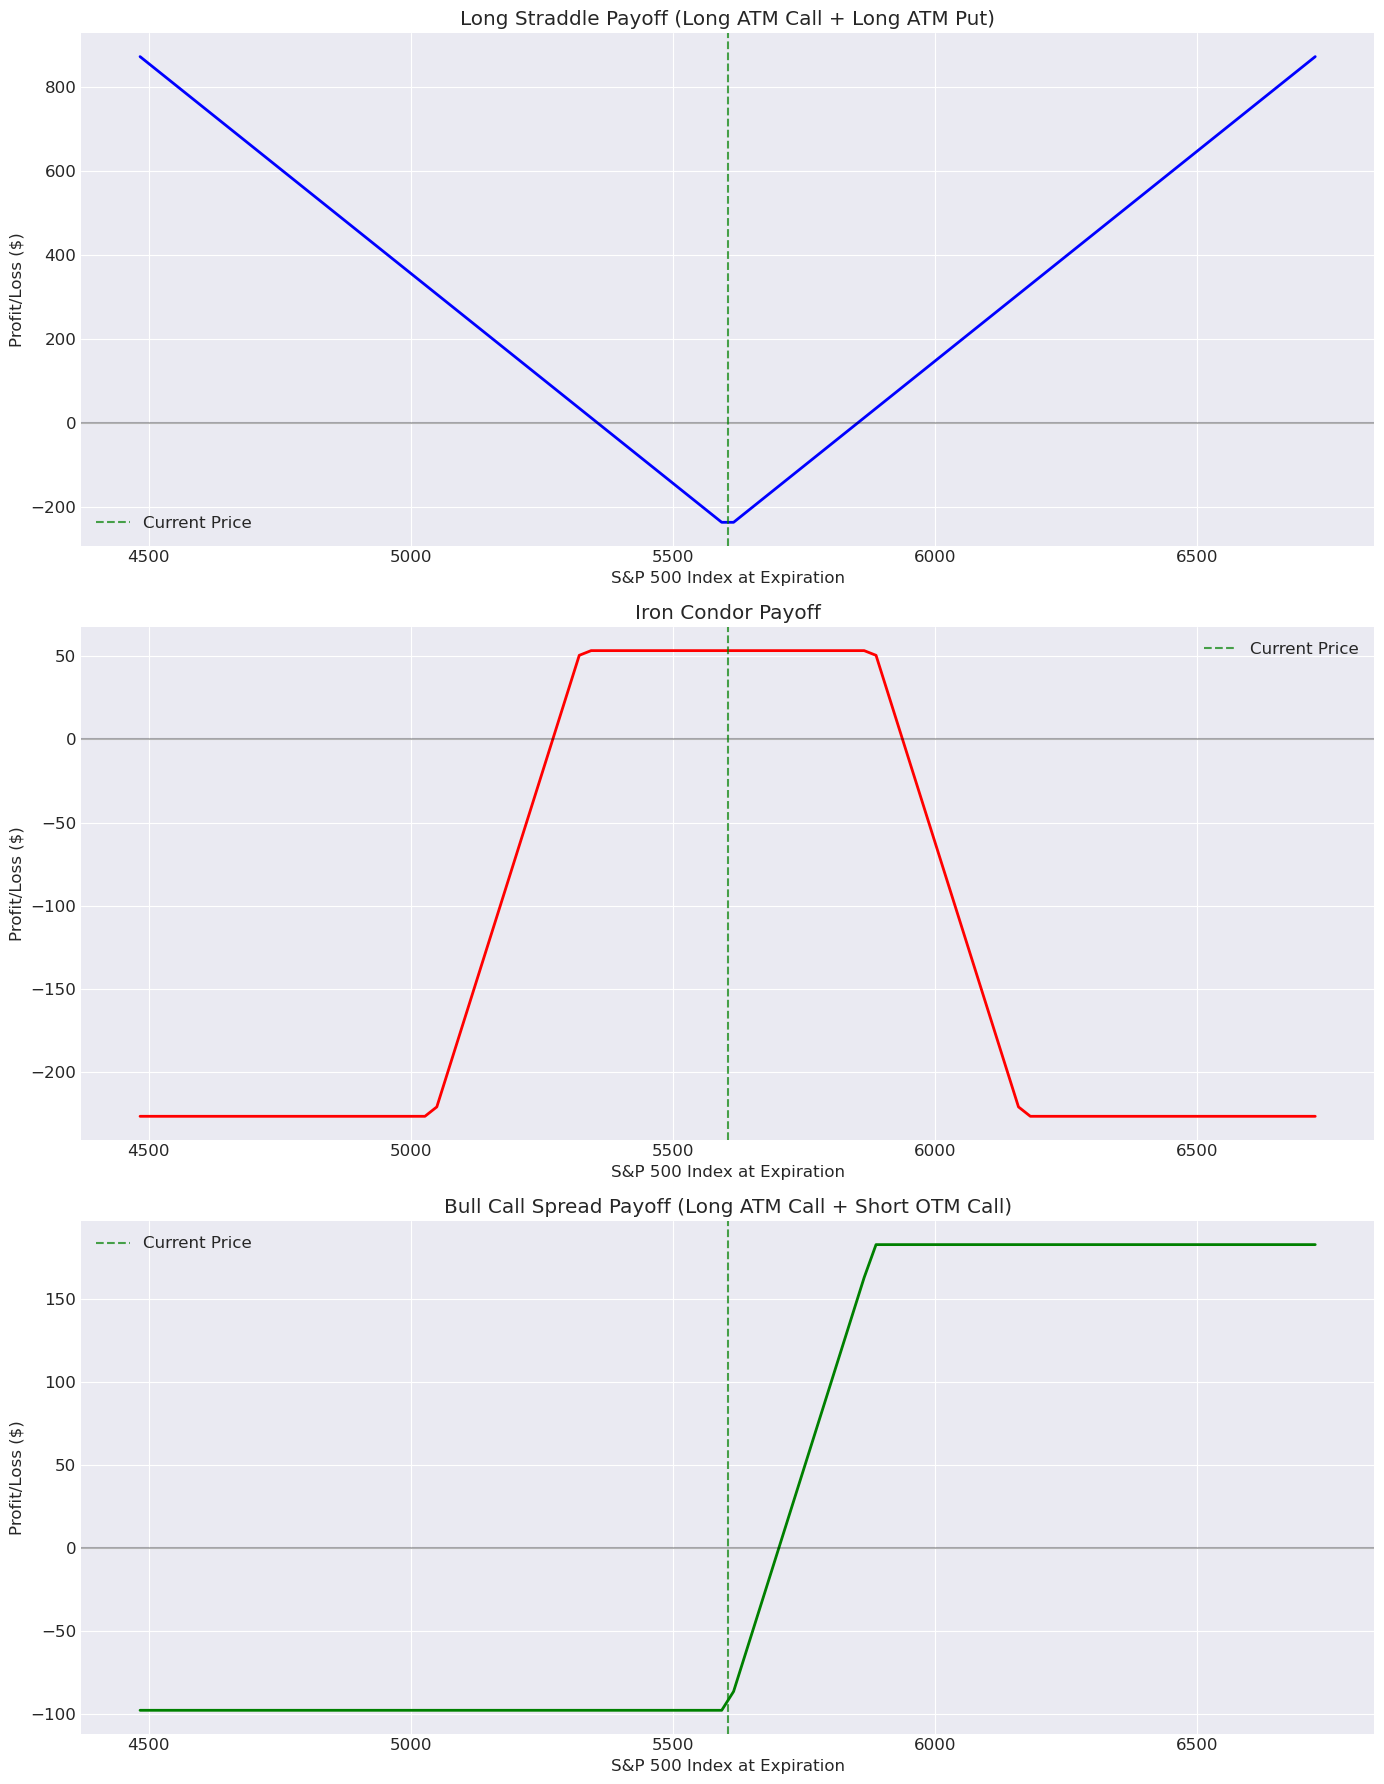

In [26]:
# Plot strategy payoffs
fig, axs = plt.subplots(3, 1, figsize=(14, 18))

# Long Straddle
axs[0].plot(straddle_payoff['Spot'], straddle_payoff['Payoff'], 'b-', linewidth=2)
axs[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axs[0].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[0].set_title('Long Straddle Payoff (Long ATM Call + Long ATM Put)')
axs[0].set_xlabel('S&P 500 Index at Expiration')
axs[0].set_ylabel('Profit/Loss ($)')
axs[0].legend()
axs[0].grid(True)

# Iron Condor
axs[1].plot(iron_condor_payoff['Spot'], iron_condor_payoff['Payoff'], 'r-', linewidth=2)
axs[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axs[1].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[1].set_title('Iron Condor Payoff')
axs[1].set_xlabel('S&P 500 Index at Expiration')
axs[1].set_ylabel('Profit/Loss ($)')
axs[1].legend()
axs[1].grid(True)

# Bull Call Spread
axs[2].plot(bull_spread_payoff['Spot'], bull_spread_payoff['Payoff'], 'g-', linewidth=2)
axs[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axs[2].axvline(x=S, color='green', linestyle='--', alpha=0.7, label='Current Price')
axs[2].set_title('Bull Call Spread Payoff (Long ATM Call + Short OTM Call)')
axs[2].set_xlabel('S&P 500 Index at Expiration')
axs[2].set_ylabel('Profit/Loss ($)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Options-Based Trading Strategies for Algorithmic Trading

Let's explore how these options pricing models and strategies can be applied in algorithmic trading of S&P 500 options.

In [27]:
# Define a simple volatility trading strategy
def volatility_trading_strategy(S, K, T, r, historical_vol, implied_vol):
    """
    A simple volatility trading strategy that:
    1. Sells options when implied volatility is higher than historical volatility
    2. Buys options when implied volatility is lower than historical volatility
    
    Uses straddles to trade volatility (both calls and puts)
    """
    vol_difference = implied_vol - historical_vol
    vol_difference_pct = vol_difference / historical_vol
    
    call_price = black_scholes(S, K, T, r, implied_vol, 'call')
    put_price = black_scholes(S, K, T, r, implied_vol, 'put')
    
    # If implied vol is significantly higher than historical, sell options (short straddle)
    if vol_difference_pct > 0.1:  # More than 10% higher
        strategy = [
            {'type': 'call', 'position': 'short', 'strike': K, 'premium': call_price, 'quantity': -1},
            {'type': 'put', 'position': 'short', 'strike': K, 'premium': put_price, 'quantity': -1}
        ]
        strategy_type = "Short Straddle (Selling Volatility)"
        
    # If implied vol is significantly lower than historical, buy options (long straddle)
    elif vol_difference_pct < -0.1:  # More than 10% lower
        strategy = [
            {'type': 'call', 'position': 'long', 'strike': K, 'premium': call_price, 'quantity': 1},
            {'type': 'put', 'position': 'long', 'strike': K, 'premium': put_price, 'quantity': 1}
        ]
        strategy_type = "Long Straddle (Buying Volatility)"
        
    # If difference is small, no trade
    else:
        strategy = []
        strategy_type = "No Trade (Volatility Fair Valued)"
    
    return {
        'strategy': strategy,
        'type': strategy_type,
        'implied_vol': implied_vol,
        'historical_vol': historical_vol,
        'vol_difference_pct': vol_difference_pct
    }

In [28]:
# Test the volatility trading strategy with different implied volatility scenarios
def test_volatility_strategy(S, historical_vol):
    """
    Test the volatility strategy with different implied volatility levels
    """
    K = S  # At-the-money options
    T = 30 / 365  # 30-day expiry
    r = 0.05  # 5% risk-free rate
    
    # Test with different implied volatility levels
    implied_vols = [historical_vol * factor for factor in [0.7, 0.85, 0.95, 1.05, 1.15, 1.3]]
    
    results = []
    for implied_vol in implied_vols:
        # Get strategy recommendation
        strategy_result = volatility_trading_strategy(S, K, T, r, historical_vol, implied_vol)
        
        # If strategy suggests a trade, calculate payoffs
        if strategy_result['strategy']:
            spot_range = np.linspace(S * 0.8, S * 1.2, 100)
            payoff = calculate_strategy_payoff(strategy_result['strategy'], spot_range)
            
            max_loss = payoff['Payoff'].min()
            max_profit = payoff['Payoff'].max()
            breakeven_points = []
            
            for i in range(1, len(payoff)):
                if (payoff['Payoff'].iloc[i-1] < 0 and payoff['Payoff'].iloc[i] >= 0) or \
                   (payoff['Payoff'].iloc[i-1] >= 0 and payoff['Payoff'].iloc[i] < 0):
                    # Linear interpolation to find breakeven point
                    x1, y1 = payoff['Spot'].iloc[i-1], payoff['Payoff'].iloc[i-1]
                    x2, y2 = payoff['Spot'].iloc[i], payoff['Payoff'].iloc[i]
                    breakeven = x1 - y1 * (x2 - x1) / (y2 - y1)
                    breakeven_points.append(breakeven)
        else:
            max_loss = 0
            max_profit = 0
            breakeven_points = []
        
        results.append({
            'Implied Vol': implied_vol,
            'Historical Vol': historical_vol,
            'Vol Difference': implied_vol - historical_vol,
            'Vol Difference %': (implied_vol - historical_vol) / historical_vol * 100,
            'Strategy': strategy_result['type'],
            'Max Loss': max_loss,
            'Max Profit': max_profit,
            'Breakeven Points': breakeven_points
        })
    
    return pd.DataFrame(results)

In [29]:
# Test the volatility trading strategy
strategy_test = test_volatility_strategy(S, historical_volatility)

# Display results
pd.set_option('display.precision', 4)
display(strategy_test)

,Implied Vol,Historical Vol,Vol Difference,Vol Difference %,Strategy,Max Loss,Max Profit,Breakeven Points
0,0.1353,0.1933,-0.0580,-30.0,Long Straddle (Buying Volatility),-162.7261,946.7804,"[5430.09252156042, 5778.18775187708]"
1,0.1643,0.1933,-0.0290,-15.0,Long Straddle (Buying Volatility),-199.6368,909.8697,"[5393.181854745488, 5815.098418692012]"
2,0.1836,0.1933,-0.0097,-5.0,No Trade (Volatility Fair Valued),0.0000,0.0000,[]
3,0.2029,0.1933,0.0097,5.0,No Trade (Volatility Fair Valued),0.0000,0.0000,[]
4,0.2223,0.1933,0.0290,15.0,Short Straddle (Selling Volatility),-835.9263,273.5803,"[5319.2383850361375, 5889.0418884013625]"
5,0.2513,0.1933,0.0580,30.0,Short Straddle (Selling Volatility),-798.9256,310.5810,"[5282.237661191706, 5926.042612245794]"


## Algorithmic Trading Applications

Options pricing models and strategies can be applied in algorithmic trading in various ways:

1. **Volatility Trading**
   - Trade the difference between implied and historical volatility
   - Implement strategies like straddles, strangles, and butterflies
   - Exploit volatility term structure or skew anomalies

2. **Delta-Neutral Strategies**
   - Maintain a delta-neutral portfolio by continuously hedging with the underlying
   - Profit from gamma and theta while minimizing directional exposure
   - Especially effective in choppy or range-bound markets

3. **Options-Based Trend Following**
   - Use options to create asymmetric risk-reward profiles for trend following
   - Buy calls or puts based on technical indicators with defined risk
   - Implement ratio spreads to enhance returns in strong trends

4. **Event-Driven Strategies**
   - Trade options around scheduled events (earnings, economic releases, Fed meetings)
   - Exploit volatility changes and mean reversion after events
   - Use iron condors or butterflies for range-bound expectations

5. **VIX-Based Strategies**
   - Use VIX and S&P 500 options together for hedging and speculation
   - Trade the relationship between realized and implied volatility
   - Implement calendar spreads based on term structure anomalies

## Conclusion

Options pricing models and strategies provide powerful tools for algorithmic trading of S&P 500 derivatives. By understanding the mathematics behind option pricing and the behavior of Greeks, traders can develop sophisticated algorithms that exploit market inefficiencies, manage risk, and generate alpha.

Key advantages of options-based algorithmic trading include:
1. Precise risk control through defined maximum losses
2. Ability to profit from volatility changes rather than just price direction
3. Leverage without the typical margin requirements of futures
4. Flexibility to create custom risk-reward profiles
5. Capability to profit in any market environment (bullish, bearish, or sideways)

However, options trading also comes with challenges, including complexity, liquidity constraints in some strikes/expirations, and the need for sophisticated execution algorithms to minimize slippage and transaction costs.